In [12]:
# Celula 1: prepara o ambiente de trabalho para toda a analise.
# Mantem a mesma estrutura do notebook XGBoost para permitir comparacao justa entre os modelos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    matthews_corrcoef, brier_score_loss, log_loss, ConfusionMatrixDisplay,
    confusion_matrix, classification_report
)

try:
    import optuna
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna

pd.set_option("display.max_columns", None)
print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


In [13]:
# Celula 2: leitura da base e preparo das variaveis de entrada.
# IMPORTANTE: esta célula replica o preprocessing do XGBoost: mesmas features, split, target encoding e scaler.
csv_path = Path("../../tabela_final/table_orders_holidays_ecommerce_events.csv") # Path(r"C:\Users\otavi\OneDrive\Desktop\last-mile-tcc\backend\tabela_final\table_orders_holidays_ecommerce_events.csv")
df = pd.read_csv(csv_path)

target_col = "delivered_on_time"
if target_col not in df.columns:
    raise ValueError(f"A coluna alvo '{target_col}' nao foi encontrada no CSV.")

# =====================================================================
# 1. ENGENHARIA DO SLA (Prazo da Transportadora - LAST MILE)
# =====================================================================
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], utc=True)
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], utc=True)
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'], utc=True)

# Quantos dias a transportadora tem para entregar apos pegar o pacote?
df['prazo_transportadora_dias'] = (df['order_estimated_delivery_date'] - df['order_delivered_carrier_date']).dt.days

# Remover os casos onde a transportadora nunca pegou o pacote para evitar NaN no treino
df = df.dropna(subset=['prazo_transportadora_dias']).copy()

# Extraindo o mes da compra (sazonalidade - Black Friday, Natal)
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
# df['carrier_month'] = df['order_delivered_carrier_date'].dt.month

# =====================================================================
# 1b. FEATURES DE INTERAÇÃO (Adicionadas para aumentar o sinal)
# =====================================================================
df['prazo_por_km'] = df['prazo_transportadora_dias'] / (df['distance_km'] + 1)
df['frete_por_kg'] = df['freight_value'] / (df['product_weight_g'] / 1000 + 0.1)
df['densidade_produto'] = df['product_weight_g'] / (df['volume_cm3'] + 1)

# =====================================================================
# 2. ORDENAÇÃO CRONOLÓGICA (Baseada no momento da coleta)
# =====================================================================
df = df.sort_values('order_delivered_carrier_date').reset_index(drop=True)

# Divide em treino/teste com split temporal (Passado treina, Futuro testa).
# Treino: ate Junho de 2018 | Teste: Julho de 2018 em diante.
date_col = df['order_delivered_carrier_date'].copy()
split_date = pd.to_datetime("2018-07-01", utc=True)

leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]
leakage_cols = [c for c in leakage_candidates if c in df.columns]

# Separa previsores e alvo.
feature_cols = [c for c in df.columns if c != target_col and c not in leakage_cols]
X = df[feature_cols].copy()
# Inverte o alvo: atraso = 1, no prazo = 0.
y = (~df[target_col].astype(bool)).astype(int).copy()

colunas_remover = [
    "order_purchase_timestamp",
    "order_approved_at",
    "interval_code_delivered_carrier", # variável n ajudou no modelo
    "interval_code_delivered_customer",
    "order_estimated_delivery_date", # Ja usamos
    "shipping_limit_date",
    "delivered_on_time",
    "review_score",
    # "had_ecommerce_event_14_days_ago",
    
    # --- FEATURES REDUNDANTES / BAIXA INFLUENCIA REMOVIDAS ---
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "holiday_at_purchase",
    "is_weekend"
]

# colunas_remover = [
#     # Vazamento de dados / multicolinearidade
#     "order_purchase_timestamp",
#     "order_approved_at",
#     "order_delivered_carrier_date",
#     "interval_code_delivered_carrier",
#     "order_delivered_customer_date",
#     "interval_code_delivered_customer",
#     "order_estimated_delivery_date",
#     "shipping_limit_date",
#     "is_holiday_in_7_days",
#     "is_holiday_in_14_days",
#     "had_holiday_7_days_ago",
#     "had_holiday_14_days_ago",
#     "delivered_on_time",
#     # "customer_city", # Mantido para Target Encoding
#     # "seller_city", # Mantido para Target Encoding
#     # "category_name", # Mantido para Target Encoding
#     "review_score",
#     "delivery_time_days"
# ]

X = X.drop(columns=colunas_remover, errors='ignore')

train_mask = date_col < split_date
test_mask = date_col >= split_date

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()

# =====================================================================
# ENGENHARIA DE FEATURES: TARGET ENCODING SUAVIZADO (Cidades)
# =====================================================================
media_global_atraso = y_train.mean()
m = 10 

# Target encoding para customer_city
counts_customer = X_train['customer_city'].value_counts()
means_customer = y_train.groupby(X_train['customer_city']).mean()
smooth_customer = (counts_customer * means_customer + m * media_global_atraso) / (counts_customer + m)

# Target encoding para seller_city
counts_seller = X_train['seller_city'].value_counts()
means_seller = y_train.groupby(X_train['seller_city']).mean()
smooth_seller = (counts_seller * means_seller + m * media_global_atraso) / (counts_seller + m)

# Aplicando as features
X_train['customer_city_encoded'] = X_train['customer_city'].map(smooth_customer)
X_train['seller_city_encoded'] = X_train['seller_city'].map(smooth_seller)

# No teste, o que não existir no treino vai preencher com a média global
X_test['customer_city_encoded'] = X_test['customer_city'].map(smooth_customer).fillna(media_global_atraso)
X_test['seller_city_encoded'] = X_test['seller_city'].map(smooth_seller).fillna(media_global_atraso)

# Target encoding para category_name (preenchendo nulos com 'Unknown')
X_train['category_name'] = X_train['category_name'].fillna('Unknown')
X_test['category_name'] = X_test['category_name'].fillna('Unknown')
counts_cat = X_train['category_name'].value_counts()
means_cat = y_train.groupby(X_train['category_name']).mean()
smooth_cat = (counts_cat * means_cat + m * media_global_atraso) / (counts_cat + m)
X_train['category_name_encoded'] = X_train['category_name'].map(smooth_cat).fillna(media_global_atraso)
X_test['category_name_encoded'] = X_test['category_name'].map(smooth_cat).fillna(media_global_atraso)

# Agora podemos dropar as strings originais
X_train = X_train.drop(columns=['customer_city', 'seller_city', 'category_name'])
X_test = X_test.drop(columns=['customer_city', 'seller_city', 'category_name'])

# =====================================================================
# STANDARDSCALER: normaliza as features numéricas (incluindo as recém criadas)
# =====================================================================
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

pos_count = int((y_train == 1).sum())
total_linhas = len(X)
qtd_treino = len(X_train)
qtd_teste = len(X_test)

print(f"Total de registros: Linhas: {X.shape[0]:,} | Colunas: {X.shape[1]}\n")
print(f"Treino (ate Jun/2018): {qtd_treino:,} ({qtd_treino/total_linhas:.2%})")
print(f" - Atrasos no Treino: {pos_count} ({(y_train == 1).mean():.2%} do treino)\n")
print(f"Teste (Jul/2018 em diante): {qtd_teste:,} ({qtd_teste/total_linhas:.2%})")
print(f" - Atrasos no Teste: {(y_test == 1).sum()} ({(y_test == 1).mean():.2%} do teste)\n")

X_test.head()

Total de registros: Linhas: 33,820 | Colunas: 26

Treino (ate Jun/2018): 28,706 (84.88%)
 - Atrasos no Treino: 1425 (4.96% do treino)

Teste (Jul/2018 em diante): 5,114 (15.12%)
 - Atrasos no Teste: 613 (11.99% do teste)



,holiday_at_carrier,days_since_last_holiday,days_until_next_holiday,ecommerce_event_at_carrier,days_since_last_ecommerce_event,days_until_next_ecommerce_event,is_ecommerce_event_in_7_days,is_ecommerce_event_in_14_days,had_ecommerce_event_7_days_ago,had_ecommerce_event_14_days_ago,purchase_hour,purchase_day_of_week,price,freight_value,product_weight_g,volume_cm3,distance_km,same_city,prazo_transportadora_dias,purchase_month,prazo_por_km,frete_por_kg,densidade_produto,customer_city_encoded,seller_city_encoded,category_name_encoded
28706,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,0.051970,1.113996,-0.275534,0.247627,-0.528927,-0.532020,-0.599951,-0.399036,0.172915,0.063254,-0.150907,1.802223,-0.228300,-1.027911,-1.149808,1.088629
28707,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,0.992364,1.113996,-0.550846,0.411442,0.251858,-0.149328,1.850664,-0.399036,0.172915,0.063254,-0.448753,-0.893705,0.076460,-0.001782,-1.732835,-2.543861
28708,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,-0.888424,1.645101,0.217681,0.349714,-0.434870,-0.571159,0.953099,-0.399036,0.783477,0.063254,-0.402380,0.422915,-0.067894,-0.001782,0.855958,0.042811
28709,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,-1.264582,1.645101,-0.356427,0.231008,-0.510769,-0.721992,0.501758,-0.399036,0.325556,0.063254,-0.392665,1.345886,0.379701,-0.846551,0.043177,0.042811
28710,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,-0.136109,1.113996,0.105127,1.406198,0.598672,1.249832,-0.266450,-0.399036,-0.742926,0.063254,-0.375918,-0.918190,-0.150108,-1.348589,-0.175591,-0.708816


In [14]:
# Celula 3: define funcoes e configuracoes da busca de hiperparametros.
# A avaliacao desta analise trata "atraso" como classe positiva (1).
def metricas_atraso(y_true, y_pred_atraso, y_proba_atraso):
    return {
        "accuracy_atraso": accuracy_score(y_true, y_pred_atraso),
        "precision_atraso": precision_score(y_true, y_pred_atraso, zero_division=0),
        "recall_atraso": recall_score(y_true, y_pred_atraso, zero_division=0),
        "f1_atraso": f1_score(y_true, y_pred_atraso, zero_division=0),
        "f2_atraso": fbeta_score(y_true, y_pred_atraso, beta=2, zero_division=0),
        "roc_auc_atraso": roc_auc_score(y_true, y_proba_atraso),
        "pr_auc_atraso": average_precision_score(y_true, y_proba_atraso),
        # "r2_atraso": r2_score(y_true, y_proba_atraso),
        "balanced_accuracy_atraso": balanced_accuracy_score(y_true, y_pred_atraso),
        "mcc_atraso": matthews_corrcoef(y_true, y_pred_atraso),
        "brier_score_atraso": brier_score_loss(y_true, y_proba_atraso),
        "log_loss_atraso": log_loss(y_true, y_proba_atraso),
    }


def metricas_gerais(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        # "R2": r2_score(y_true, y_proba),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Brier Score": brier_score_loss(y_true, y_proba),
        "Log Loss": log_loss(y_true, y_proba),
    }

# Configuracao do Optuna para busca de hiperparametros.
n_trials = 50
study_seed = 42
cv_tune = TimeSeriesSplit(n_splits=5)
threshold_grid_tune = np.arange(0.05, 0.81, 0.01)

# Vetor binario: 1 = atraso, 0 = nao atraso.
y_train_atraso = y_train.values

# Mantemos a mesma lógica REAL do notebook XGBoost enviado:
# ele calcula a razão entre classes, mas não aplica scale_pos_weight no objective().
# Por isso, para uma comparação estritamente equivalente, a árvore também não recebe class_weight.
# Se o XGBoost passar a tunar scale_pos_weight futuramente, esta árvore deve ser atualizada para tunar class_weight.
neg_count = int((y_train == 0).sum())
pos_count_train = int((y_train == 1).sum())
max_spw = neg_count / pos_count_train  # ~19, usado como limite superior

print("Preparacao da busca de hiperparametros concluida.")

Preparacao da busca de hiperparametros concluida.


In [15]:
# Celula 4: busca de hiperparametros com Optuna + validacao cruzada temporal.
# Mesmo criterio do XGBoost: maximizar PR-AUC; threshold escolhido por F1,
# com desempate por Recall e depois Precision da classe atraso (1).
#
# Os hiperparametros abaixo sao proprios da Arvore de Decisao.
# Nao faria sentido copiar learning_rate, n_estimators, gamma etc. do XGBoost,
# pois eles nao existem em DecisionTreeClassifier.

optuna_db_path = Path("optuna_arvore_temporal.db").resolve()
study_storage = f"sqlite:///{optuna_db_path.as_posix()}"
study_name = "arvore_temporal_equivalente_xgb_v1"

def objective(trial):
    params = {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 10, 200, step=10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 100, step=5),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.02),
    }

    oof_proba_atraso = np.zeros(len(y_train), dtype=float)
    valid_mask = np.zeros(len(y_train), dtype=bool)

    for fold, (tr_idx, va_idx) in enumerate(cv_tune.split(X_train, y_train), start=1):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        mdl = DecisionTreeClassifier(
            random_state=1000 + trial.number * 10 + fold,
            **params,
        )
        mdl.fit(X_tr, y_tr)

        proba_atraso_va = mdl.predict_proba(X_va)[:, 1]
        oof_proba_atraso[va_idx] = proba_atraso_va
        valid_mask[va_idx] = True

    # TimeSeriesSplit nao usa o bloco inicial como validacao.
    # Calculamos as metricas apenas nos registros que realmente receberam predicao OOF.
    y_oof = y_train_atraso[valid_mask]
    proba_oof = oof_proba_atraso[valid_mask]
    pr_auc_i = average_precision_score(y_oof, proba_oof)

    best_thr_i = 0.50
    best_f1_i = -1.0
    best_recall_i = -1.0
    best_precision_i = -1.0

    for thr in threshold_grid_tune:
        pred_atraso = (proba_oof >= thr).astype(int)
        precision_i = precision_score(y_oof, pred_atraso, zero_division=0)
        recall_i = recall_score(y_oof, pred_atraso, zero_division=0)
        f1_i = f1_score(y_oof, pred_atraso, zero_division=0)

        if (f1_i > best_f1_i) or (
            np.isclose(f1_i, best_f1_i) and recall_i > best_recall_i
        ) or (
            np.isclose(f1_i, best_f1_i)
            and np.isclose(recall_i, best_recall_i)
            and precision_i > best_precision_i
        ):
            best_f1_i = float(f1_i)
            best_recall_i = float(recall_i)
            best_precision_i = float(precision_i)
            best_thr_i = float(thr)

    trial.set_user_attr("best_threshold", best_thr_i)
    trial.set_user_attr("cv_pr_auc_atraso", pr_auc_i)
    trial.set_user_attr("cv_f1_atraso", best_f1_i)
    trial.set_user_attr("cv_recall_atraso", best_recall_i)
    trial.set_user_attr("cv_precision_atraso", best_precision_i)
    return pr_auc_i

sampler = optuna.samplers.TPESampler(seed=study_seed)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name=study_name,
    storage=study_storage,
    load_if_exists=True,
)
study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

best_trial = study.best_trial
best_params_v2 = best_trial.params
best_threshold_v2 = float(best_trial.user_attrs["best_threshold"])

tuning_rows = []
for t in study.trials:
    if t.value is None:
        continue
    tuning_rows.append({
        "candidate": t.number + 1,
        "cv_pr_auc_atraso": t.user_attrs.get("cv_pr_auc_atraso", np.nan),
        "cv_f1_atraso": t.user_attrs.get("cv_f1_atraso", np.nan),
        "cv_recall_atraso": t.user_attrs.get("cv_recall_atraso", np.nan),
        "cv_precision_atraso": t.user_attrs.get("cv_precision_atraso", np.nan),
        "best_threshold": t.user_attrs.get("best_threshold", np.nan),
        "params": t.params,
    })

df_tuning = pd.DataFrame(tuning_rows).sort_values(
    ["cv_pr_auc_atraso", "cv_f1_atraso", "cv_recall_atraso", "cv_precision_atraso"],
    ascending=False
).reset_index(drop=True)

print(f"Trials avaliados: {len(df_tuning)}")
print("Top 8 configuracoes pela validacao cruzada (PR-AUC -> F1 -> Recall):")
display(df_tuning.head(8))
print("\nMelhores hiperparametros encontrados:")
for key, value in best_params_v2.items():
    print(f" - {key}: {value}")
print(f"Melhor limiar (Optuna): {best_threshold_v2:.2f}")
print(f"Study name: {study_name}")


[I 2026-10-04 16:19:48,312] Using an existing study with `study_name='arvore_temporal_equivalente_xgb_v1'` instead of creating a new one.
[I 2026-10-04 16:19:49,748] Trial 50 finished with value: 0.3154748616758409 and parameters: {'criterion': 'log_loss', 'max_depth': 5, 'min_samples_split': 80, 'min_samples_leaf': 5, 'max_features': None, 'ccp_alpha': 0.0014532876051912835}. Best is trial 31 with value: 0.32045050008530374.
[I 2026-10-04 16:19:51,025] Trial 51 finished with value: 0.31975041718393504 and parameters: {'criterion': 'log_loss', 'max_depth': 5, 'min_samples_split': 90, 'min_samples_leaf': 20, 'max_features': None, 'ccp_alpha': 7.943115230943983e-05}. Best is trial 31 with value: 0.32045050008530374.
[I 2026-10-04 16:19:52,277] Trial 52 finished with value: 0.29176334042734775 and parameters: {'criterion': 'log_loss', 'max_depth': 3, 'min_samples_split': 90, 'min_samples_leaf': 15, 'max_features': None, 'ccp_alpha': 0.0020708576487491036}. Best is trial 31 with value: 0.3

Trials avaliados: 100
Top 8 configuracoes pela validacao cruzada (PR-AUC -> F1 -> Recall):


,candidate,cv_pr_auc_atraso,cv_f1_atraso,cv_recall_atraso,cv_precision_atraso,best_threshold,params
0,85,0.328045,0.340782,0.301731,0.391444,0.25,"{'criterion': 'log_loss', 'max_depth': 8, 'min..."
1,98,0.327150,0.339877,0.228359,0.664269,0.40,"{'criterion': 'log_loss', 'max_depth': 8, 'min..."
2,94,0.325708,0.329238,0.276175,0.407543,0.24,"{'criterion': 'log_loss', 'max_depth': 8, 'min..."
3,97,0.325020,0.328740,0.275350,0.407814,0.24,"{'criterion': 'log_loss', 'max_depth': 8, 'min..."
4,71,0.323622,0.349151,0.245672,0.603239,0.31,"{'criterion': 'log_loss', 'max_depth': 5, 'min..."
5,99,0.323390,0.339877,0.228359,0.664269,0.40,"{'criterion': 'log_loss', 'max_depth': 9, 'min..."
6,92,0.323314,0.329180,0.261336,0.444600,0.26,"{'criterion': 'log_loss', 'max_depth': 9, 'min..."
7,74,0.322967,0.330717,0.260511,0.452722,0.26,"{'criterion': 'log_loss', 'max_depth': 6, 'min..."



Melhores hiperparametros encontrados:
 - criterion: log_loss
 - max_depth: 8
 - min_samples_split: 40
 - min_samples_leaf: 90
 - max_features: None
 - ccp_alpha: 6.441020532934867e-05
Melhor limiar (Optuna): 0.25
Study name: arvore_temporal_equivalente_xgb_v1


Metricas no teste (foco em atraso = classe 1):


,Teste
accuracy_atraso,0.8203
precision_atraso,0.3719
recall_atraso,0.7243
f1_atraso,0.4914
f2_atraso,0.6089
roc_auc_atraso,0.8840
pr_auc_atraso,0.6663
balanced_accuracy_atraso,0.7788
mcc_atraso,0.4282
brier_score_atraso,0.0743


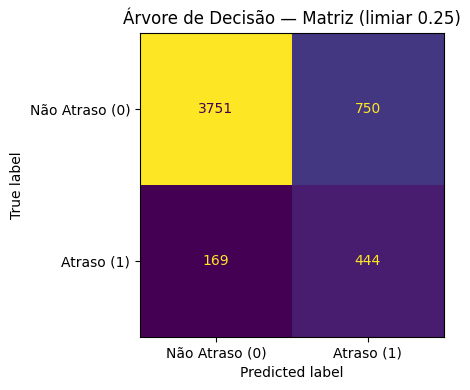


Classification report:
              precision    recall  f1-score   support

  Não Atraso       0.96      0.83      0.89      4501
      Atraso       0.37      0.72      0.49       613

    accuracy                           0.82      5114
   macro avg       0.66      0.78      0.69      5114
weighted avg       0.89      0.82      0.84      5114



In [16]:
# Celula 5: treino final + avaliacao no teste temporal.
model_v2 = DecisionTreeClassifier(
    random_state=4242,
    **best_params_v2,
)
model_v2.fit(X_train, y_train)

y_proba_v2_train = model_v2.predict_proba(X_train)[:, 1]
y_proba_v2_test = model_v2.predict_proba(X_test)[:, 1]

y_pred_v2_train = (y_proba_v2_train >= best_threshold_v2).astype(int)
y_pred_v2_test = (y_proba_v2_test >= best_threshold_v2).astype(int)

res_v2_train = metricas_atraso(y_train, y_pred_v2_train, y_proba_v2_train)
res_v2_test = metricas_atraso(y_test, y_pred_v2_test, y_proba_v2_test)
metricas_treino_v2 = metricas_gerais(y_train, y_pred_v2_train, y_proba_v2_train)
metricas_teste_v2 = metricas_gerais(y_test, y_pred_v2_test, y_proba_v2_test)

print("Metricas no teste (foco em atraso = classe 1):")
display(pd.DataFrame(pd.Series(res_v2_test, name="Teste")).round(4))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_v2_test, ax=ax, colorbar=False,
    display_labels=["Não Atraso (0)", "Atraso (1)"]
)
ax.set_title(f"Árvore de Decisão — Matriz (limiar {best_threshold_v2:.2f})")
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_test, y_pred_v2_test, target_names=["Não Atraso", "Atraso"], zero_division=0))


In [17]:
# Celula 6: tabela de metricas equivalente a do XGBoost.
print("=" * 120)
print("METRICAS DE ATRASO (CLASSE 1)")
print("=" * 120)
print("\nTREINO")
display(pd.DataFrame(pd.Series(res_v2_train, name="Treino")).round(4))
print("\nTESTE")
display(pd.DataFrame(pd.Series(res_v2_test, name="Teste")).round(4))

comparacao_treino_teste = pd.DataFrame({
    "Metrica": ["Accuracy", "Precision atraso", "Recall atraso", "F1 atraso", "F2 atraso", "ROC-AUC", "PR-AUC"],
    "Treino": [
        metricas_treino_v2["Accuracy"], res_v2_train["precision_atraso"], res_v2_train["recall_atraso"],
        res_v2_train["f1_atraso"], res_v2_train["f2_atraso"], res_v2_train["roc_auc_atraso"],
        res_v2_train["pr_auc_atraso"]
    ],
    "Teste": [
        metricas_teste_v2["Accuracy"], res_v2_test["precision_atraso"], res_v2_test["recall_atraso"],
        res_v2_test["f1_atraso"], res_v2_test["f2_atraso"], res_v2_test["roc_auc_atraso"],
        res_v2_test["pr_auc_atraso"]
    ],
})
comparacao_treino_teste["Gap (Treino-Teste)"] = comparacao_treino_teste["Treino"] - comparacao_treino_teste["Teste"]
print("\nCOMPARAÇÃO TREINO X TESTE — útil para diagnosticar overfitting")
display(comparacao_treino_teste.round(4))


METRICAS DE ATRASO (CLASSE 1)

TREINO


,Treino
accuracy_atraso,0.9544
precision_atraso,0.5653
recall_atraso,0.3495
f1_atraso,0.4319
f2_atraso,0.3784
roc_auc_atraso,0.8668
pr_auc_atraso,0.4445
balanced_accuracy_atraso,0.6677
mcc_atraso,0.4224
brier_score_atraso,0.0349



TESTE


,Teste
accuracy_atraso,0.8203
precision_atraso,0.3719
recall_atraso,0.7243
f1_atraso,0.4914
f2_atraso,0.6089
roc_auc_atraso,0.8840
pr_auc_atraso,0.6663
balanced_accuracy_atraso,0.7788
mcc_atraso,0.4282
brier_score_atraso,0.0743



COMPARAÇÃO TREINO X TESTE — útil para diagnosticar overfitting


,Metrica,Treino,Teste,Gap (Treino-Teste)
0,Accuracy,0.9544,0.8203,0.1341
1,Precision atraso,0.5653,0.3719,0.1934
2,Recall atraso,0.3495,0.7243,-0.3748
3,F1 atraso,0.4319,0.4914,-0.0595
4,F2 atraso,0.3784,0.6089,-0.2305
5,ROC-AUC,0.8668,0.8840,-0.0173
6,PR-AUC,0.4445,0.6663,-0.2218


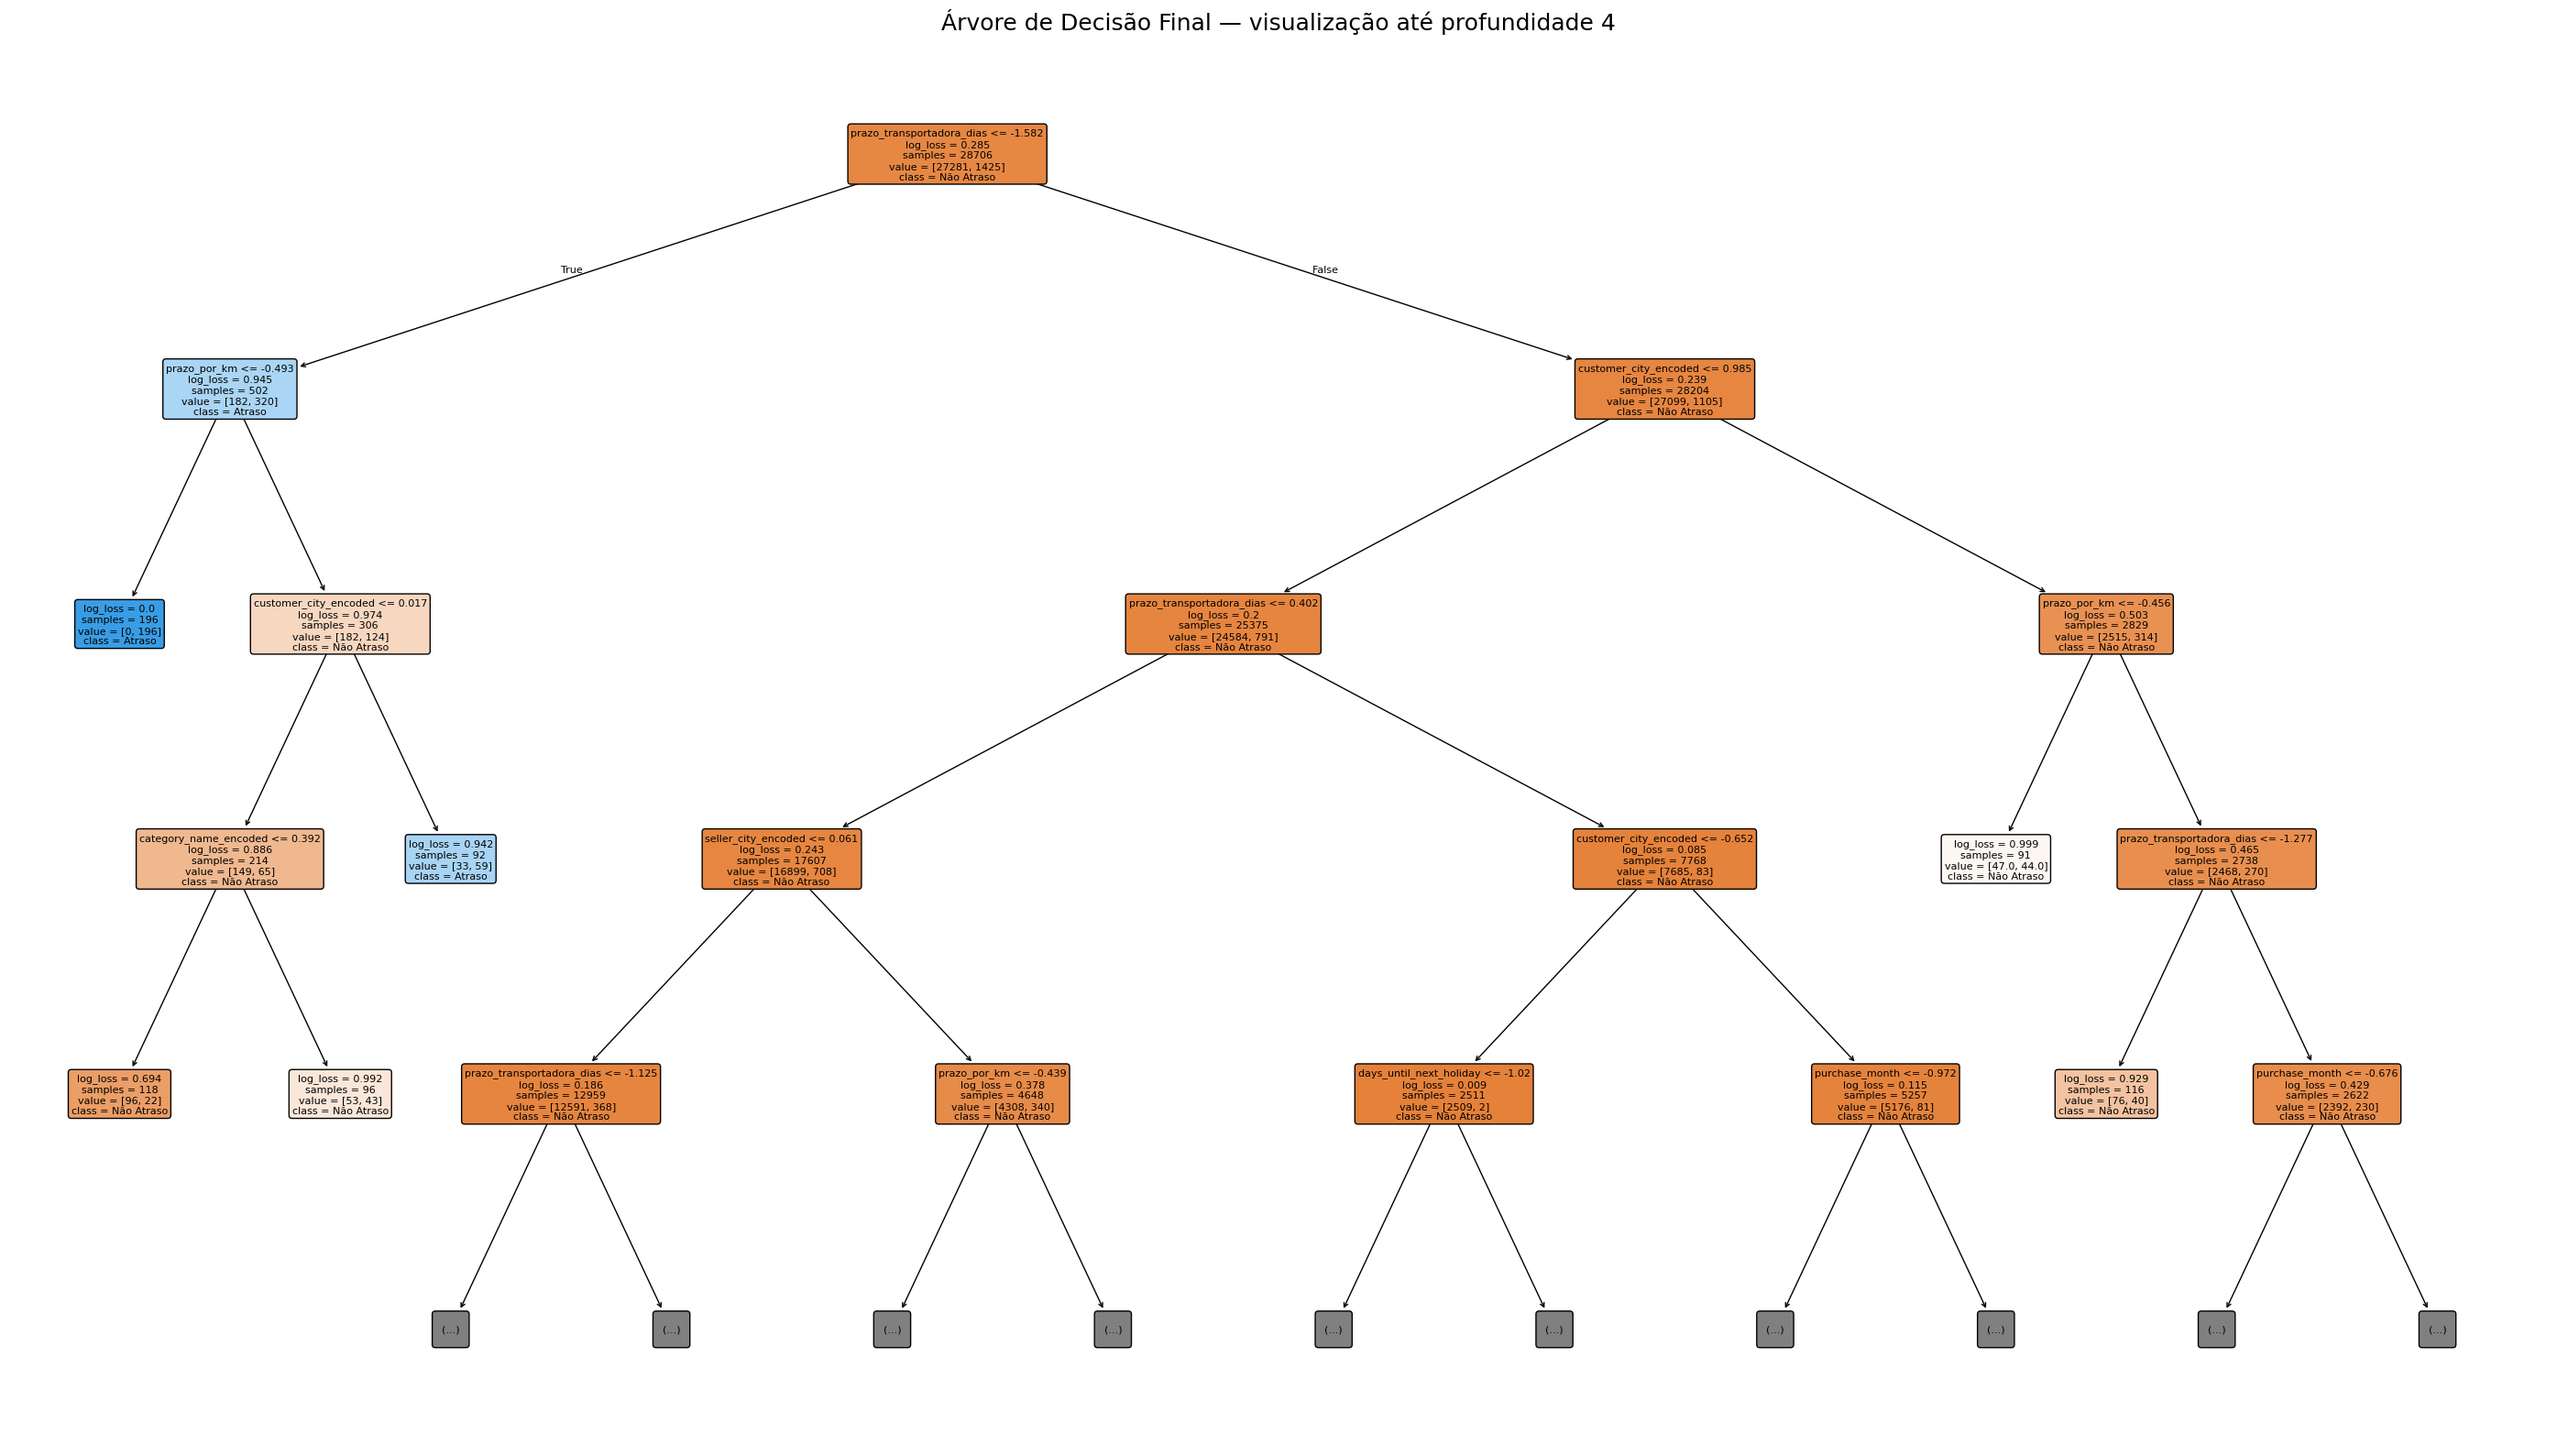

Profundidade completa: 8
Quantidade de folhas: 63
Quantidade total de nós: 125
Número de features disponíveis: 26

INSIGHT:
- Uma árvore muito profunda e com muitas folhas pode memorizar padrões do treino.
- Compare a complexidade acima com os gaps treino-teste da célula anterior.
- A visualização foi limitada a 4 níveis apenas para permitir interpretação das regras principais.


In [18]:
# Celula 7: INSIGHT ESPECIFICO DA ARVORE — estrutura, complexidade e regras.
plt.figure(figsize=(28, 16))
plot_tree(
    model_v2,
    feature_names=X_train.columns.tolist(),
    class_names=["Não Atraso", "Atraso"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4
)
plt.title("Árvore de Decisão Final — visualização até profundidade 4", fontsize=18)
plt.tight_layout()
plt.show()

print("Profundidade completa:", model_v2.get_depth())
print("Quantidade de folhas:", model_v2.get_n_leaves())
print("Quantidade total de nós:", model_v2.tree_.node_count)
print("Número de features disponíveis:", model_v2.n_features_in_)

print("\nINSIGHT:")
print("- Uma árvore muito profunda e com muitas folhas pode memorizar padrões do treino.")
print("- Compare a complexidade acima com os gaps treino-teste da célula anterior.")
print("- A visualização foi limitada a 4 níveis apenas para permitir interpretação das regras principais.")


=== Importância das features — Árvore de Decisão ===


,feature,importance,importance_pct
0,prazo_transportadora_dias,0.5072,50.7179
1,prazo_por_km,0.1344,13.4377
2,customer_city_encoded,0.1323,13.2275
3,seller_city_encoded,0.0500,5.0008
4,purchase_month,0.0364,3.6425
5,days_until_next_ecommerce_event,0.0322,3.2218
6,freight_value,0.0289,2.8887
7,days_since_last_ecommerce_event,0.0159,1.5925
8,densidade_produto,0.0159,1.5869
9,volume_cm3,0.0109,1.0867


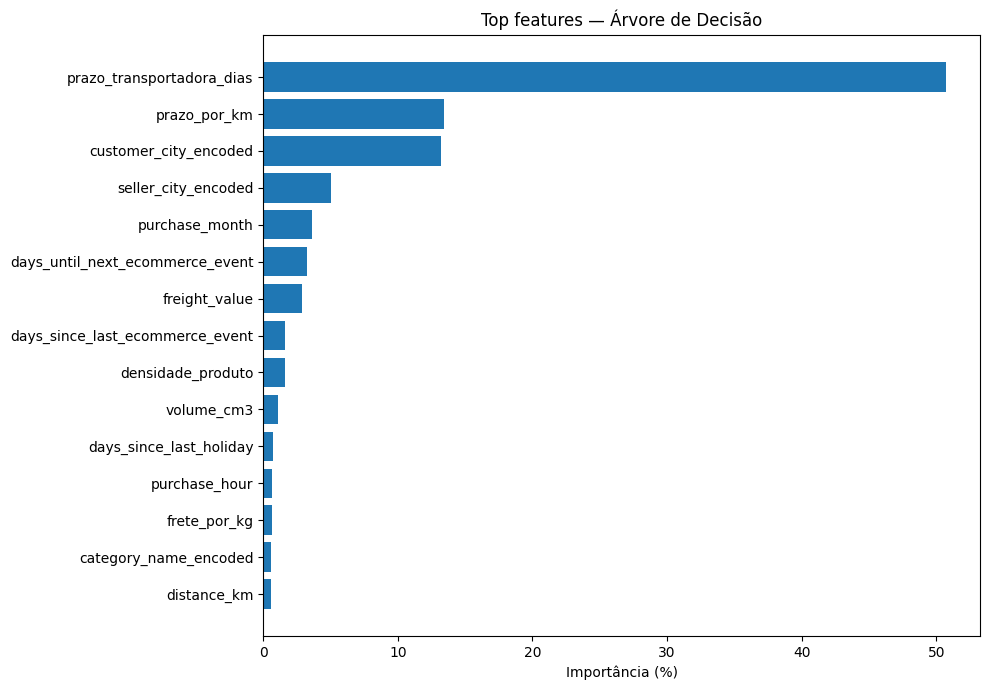


INSIGHTS:
- As primeiras posições mostram quais variáveis mais contribuíram para as divisões da árvore.
- Importância igual a zero indica que a feature não foi utilizada em nenhuma divisão do modelo final.
- Em árvores, a importância deve ser interpretada junto com as regras e com as métricas de generalização;
  uma feature muito dominante não significa, sozinha, relação causal com o atraso.


In [19]:
# Celula 8: INSIGHT ESPECIFICO DA ARVORE — importancia das features.
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_v2.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df["importance_pct"] = importance_df["importance"] * 100

print("=== Importância das features — Árvore de Decisão ===")
display(importance_df.round(4))

top_n = min(15, len(importance_df))
plot_df = importance_df.head(top_n).sort_values("importance_pct")
plt.figure(figsize=(10, 7))
plt.barh(plot_df["feature"], plot_df["importance_pct"])
plt.xlabel("Importância (%)")
plt.title("Top features — Árvore de Decisão")
plt.tight_layout()
plt.show()

print("\nINSIGHTS:")
print("- As primeiras posições mostram quais variáveis mais contribuíram para as divisões da árvore.")
print("- Importância igual a zero indica que a feature não foi utilizada em nenhuma divisão do modelo final.")
print("- Em árvores, a importância deve ser interpretada junto com as regras e com as métricas de generalização;")
print("  uma feature muito dominante não significa, sozinha, relação causal com o atraso.")


In [20]:
# Celula 9: comparação do threshold otimizado contra 0.50.
pred_default = (y_proba_v2_test >= 0.50).astype(int)
pred_tuned = y_pred_v2_test

def resumo_threshold(y_true, pred, proba, nome):
    return {
        "Cenario": nome,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision atraso": precision_score(y_true, pred, zero_division=0),
        "Recall atraso": recall_score(y_true, pred, zero_division=0),
        "F1 atraso": f1_score(y_true, pred, zero_division=0),
        "F2 atraso": fbeta_score(y_true, pred, beta=2, zero_division=0),
        "PR-AUC": average_precision_score(y_true, proba),
    }

comparacao_threshold = pd.DataFrame([
    resumo_threshold(y_test, pred_default, y_proba_v2_test, "Threshold 0.50"),
    resumo_threshold(y_test, pred_tuned, y_proba_v2_test, f"Threshold otimizado {best_threshold_v2:.2f}"),
])
display(comparacao_threshold.round(4))

print("\nINSIGHT:")
print("- O threshold não altera a árvore treinada nem as probabilidades; ele altera a decisão final de classe.")
print("- Para o TCC, observe principalmente o efeito em Recall/F2 de atraso versus Precision.")


,Cenario,Accuracy,Precision atraso,Recall atraso,F1 atraso,F2 atraso,PR-AUC
0,Threshold 0.50,0.9132,0.6517,0.5922,0.6205,0.6032,0.6663
1,Threshold otimizado 0.25,0.8203,0.3719,0.7243,0.4914,0.6089,0.6663



INSIGHT:
- O threshold não altera a árvore treinada nem as probabilidades; ele altera a decisão final de classe.
- Para o TCC, observe principalmente o efeito em Recall/F2 de atraso versus Precision.


In [21]:
# Celula 10: resumo final com os principais insights da Arvore de Decisao.
print("=" * 100)
print("RESUMO FINAL — ARVORE DE DECISAO")
print("=" * 100)
print(f"Threshold escolhido na validação temporal: {best_threshold_v2:.2f}")
print(f"Profundidade: {model_v2.get_depth()} | Folhas: {model_v2.get_n_leaves()} | Nós: {model_v2.tree_.node_count}")
print("\nMelhores hiperparâmetros:")
for k, v in best_params_v2.items():
    print(f" - {k}: {v}")

print("\nMétricas de atraso no TESTE:")
for k in ["precision_atraso", "recall_atraso", "f1_atraso", "f2_atraso", "roc_auc_atraso", "pr_auc_atraso"]:
    print(f" - {k}: {res_v2_test[k]:.4f}")

print("\nTop 10 features:")
display(importance_df.head(10).round(4))

print("\nLEITURA PARA O TCC:")
print("1. Generalização: use os gaps treino-teste para verificar se a árvore está sofrendo overfitting.")
print("2. Classe minoritária: priorize PR-AUC, Recall, F1 e F2 de atraso, não apenas Accuracy.")
print("3. Interpretabilidade: profundidade, folhas e regras tornam a árvore mais explicável que modelos de ensemble.")
print("4. Features: discuta as variáveis mais importantes como sinais preditivos, sem tratá-las automaticamente como causas.")
print("5. Threshold: o limiar otimizado mostra o trade-off entre detectar mais atrasos e gerar falsos positivos.")


RESUMO FINAL — ARVORE DE DECISAO
Threshold escolhido na validação temporal: 0.25
Profundidade: 8 | Folhas: 63 | Nós: 125

Melhores hiperparâmetros:
 - criterion: log_loss
 - max_depth: 8
 - min_samples_split: 40
 - min_samples_leaf: 90
 - max_features: None
 - ccp_alpha: 6.441020532934867e-05

Métricas de atraso no TESTE:
 - precision_atraso: 0.3719
 - recall_atraso: 0.7243
 - f1_atraso: 0.4914
 - f2_atraso: 0.6089
 - roc_auc_atraso: 0.8840
 - pr_auc_atraso: 0.6663

Top 10 features:


,feature,importance,importance_pct
0,prazo_transportadora_dias,0.5072,50.7179
1,prazo_por_km,0.1344,13.4377
2,customer_city_encoded,0.1323,13.2275
3,seller_city_encoded,0.0500,5.0008
4,purchase_month,0.0364,3.6425
5,days_until_next_ecommerce_event,0.0322,3.2218
6,freight_value,0.0289,2.8887
7,days_since_last_ecommerce_event,0.0159,1.5925
8,densidade_produto,0.0159,1.5869
9,volume_cm3,0.0109,1.0867



LEITURA PARA O TCC:
1. Generalização: use os gaps treino-teste para verificar se a árvore está sofrendo overfitting.
2. Classe minoritária: priorize PR-AUC, Recall, F1 e F2 de atraso, não apenas Accuracy.
3. Interpretabilidade: profundidade, folhas e regras tornam a árvore mais explicável que modelos de ensemble.
4. Features: discuta as variáveis mais importantes como sinais preditivos, sem tratá-las automaticamente como causas.
5. Threshold: o limiar otimizado mostra o trade-off entre detectar mais atrasos e gerar falsos positivos.


In [24]:
# Celula final: salva o modelo e todos os artefatos necessarios para inferencia em producao.
import pickle

artefato_modelo = {
    # Modelo final treinado
    "model": model_v2,

    # Pre-processamento
    "scaler": scaler,
    "feature_names": X_train.columns.tolist(),

    # Target Encoding aprendido SOMENTE com o treino
    "target_encoding": {
        "customer_city": smooth_customer.to_dict(),
        "seller_city": smooth_seller.to_dict(),
        "category_name": smooth_cat.to_dict(),
        "global_mean": float(media_global_atraso),
    },

    # Limiar escolhido pelo Optuna/validacao temporal
    "threshold": float(best_threshold_v2),

    # Hiperparametros para rastreabilidade
    "best_params": best_params_v2,

    # Convencao do alvo
    "target_definition": {
        "0": "nao_atraso",
        "1": "atraso"
    }
}

nome_arquivo = "arvore_decisao_last_mile.pkl"

with open(nome_arquivo, "wb") as arquivo:
    pickle.dump(artefato_modelo, arquivo, protocol=pickle.HIGHEST_PROTOCOL)

print(f"PKL salvo com sucesso: {nome_arquivo}")
print(f"Features salvas: {len(artefato_modelo['feature_names'])}")
print(f"Threshold salvo: {artefato_modelo['threshold']:.2f}")
print("Modelo: DecisionTreeClassifier (model_v2)")

PKL salvo com sucesso: arvore_decisao_last_mile.pkl
Features salvas: 26
Threshold salvo: 0.25
Modelo: DecisionTreeClassifier (model_v2)
